# Car Cost Prediction using Multiple Linear Regression

This rewritten notebook trains a car price prediction model using **Multiple Linear Regression (MLR)** from `scikit-learn`.

Workflow:
- Load the used-car dataset
- Clean `price` and `milage`
- Prepare numeric and categorical features
- Use `ColumnTransformer`, `OneHotEncoder`, `StandardScaler`, and `LinearRegression`
- Evaluate using MAE, RMSE, R2, and adjusted R2
- Predict a sample used-car price


## 1. Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


## 2. Load Dataset


In [2]:
df = pd.read_csv("used_cars.csv")

## 3. Basic Dataset Checks


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [4]:
df.isnull().sum().sort_values(ascending=False)


,0
clean_title,596
fuel_type,170
accident,113
brand,0
milage,0
model_year,0
model,0
engine,0
ext_col,0
transmission,0


In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,4009,57,Ford,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,4009,1898,M3 Base,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,4009.0,NaN,NaN,NaN,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
milage,4009,2818,"110,000 mi.",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,3839,7,Gasoline,3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,4009,1146,2.0L I4 16V GDI DOHC Turbo,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4009,62,A/T,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext_col,4009,319,Black,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_col,4009,156,Black,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident,3896,2,None reported,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Clean Numeric Columns


In [6]:
data = df.copy()

data["price"] = data["price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
data["milage"] = data["milage"].astype(str).str.replace("mi.", "", regex=False).str.replace(",", "", regex=False).astype(float)

data[["price", "milage", "model_year"]].head()


,price,milage,model_year
0,10300.0,51000.0,2013
1,38005.0,34742.0,2021
2,54598.0,22372.0,2022
3,15500.0,88900.0,2015
4,34999.0,9835.0,2021


## 5. Feature Engineering


In [7]:
current_year = 2026
data["car_age"] = current_year - data["model_year"]
data["car_age"] = data["car_age"].clip(lower=0)

data["fuel_type"] = data["fuel_type"].replace("–", "Gasoline").fillna("Gasoline")
data["accident"] = data["accident"].fillna("None reported")
data["clean_title"] = data["clean_title"].fillna("Unknown")

def clean_transmission(value):
    value = str(value).lower()
    if "manual" in value or "m/t" in value:
        return "Manual"
    if "cvt" in value:
        return "CVT"
    if "dual" in value or "dct" in value:
        return "Dual-Clutch"
    if "auto" in value or "a/t" in value:
        return "Automatic"
    return "Other"

data["transmission"] = data["transmission"].apply(clean_transmission)

def extract_hp(engine):
    match = re.search(r"(\d+(?:\.\d+)?)\s*HP", str(engine), flags=re.I)
    return float(match.group(1)) if match else np.nan

def extract_liters(engine):
    match = re.search(r"(\d+(?:\.\d+)?)\s*L", str(engine), flags=re.I)
    return float(match.group(1)) if match else np.nan

def extract_cylinders(engine):
    text = str(engine).lower()
    match = re.search(r"v\s?(\d+)|i\s?(\d+)|(\d+)\s*cylinder", text)
    if not match:
        return np.nan
    for group in match.groups():
        if group:
            return float(group)
    return np.nan

data["horsepower"] = data["engine"].apply(extract_hp)
data["engine_liters"] = data["engine"].apply(extract_liters)
data["cylinders"] = data["engine"].apply(extract_cylinders)
data["log_milage"] = np.log1p(data["milage"])
data["age_mileage"] = data["car_age"] * data["log_milage"]

brand_threshold = 15
brand_counts = data["brand"].value_counts()
valid_brands = brand_counts[brand_counts >= brand_threshold].index
data["brand_group"] = data["brand"].where(data["brand"].isin(valid_brands), "Other")

data[["brand", "brand_group", "fuel_type", "transmission", "accident", "clean_title", "horsepower", "engine_liters", "cylinders"]].head()


,brand,brand_group,fuel_type,transmission,accident,clean_title,horsepower,engine_liters,cylinders
0,Ford,Ford,E85 Flex Fuel,Automatic,At least 1 accident or damage reported,Yes,300.0,3.7,6.0
1,Hyundai,Hyundai,Gasoline,Automatic,At least 1 accident or damage reported,Yes,NaN,3.8,6.0
2,Lexus,Lexus,Gasoline,Automatic,None reported,Unknown,NaN,3.5,NaN
3,INFINITI,INFINITI,Hybrid,Automatic,None reported,Yes,354.0,3.5,6.0
4,Audi,Audi,Gasoline,Automatic,None reported,Unknown,NaN,2.0,4.0


## 6. Remove Missing Values and Extreme Outliers


In [8]:
model_data = data.dropna(subset=["price", "milage", "model_year", "car_age"]).copy()
model_data = model_data[model_data["price"] < 300000].copy()

print("Cleaned shape:", model_data.shape)
print("Price range:", model_data["price"].min(), "to", model_data["price"].max())


Cleaned shape: (3981, 19)
Price range: 2000.0 to 299000.0


## 7. Exploratory Data Analysis


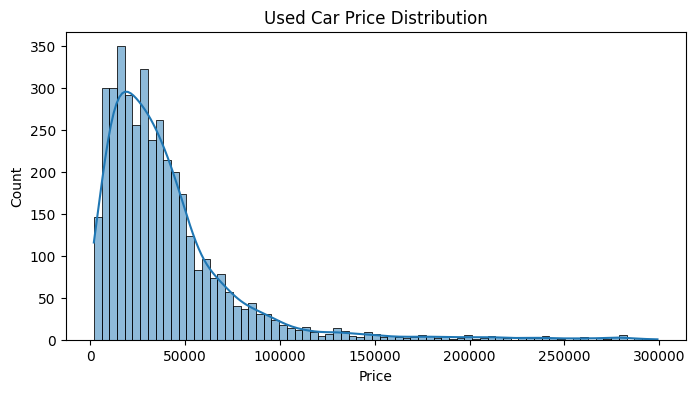

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(model_data["price"], kde=True)
plt.title("Used Car Price Distribution")
plt.xlabel("Price")
plt.show()


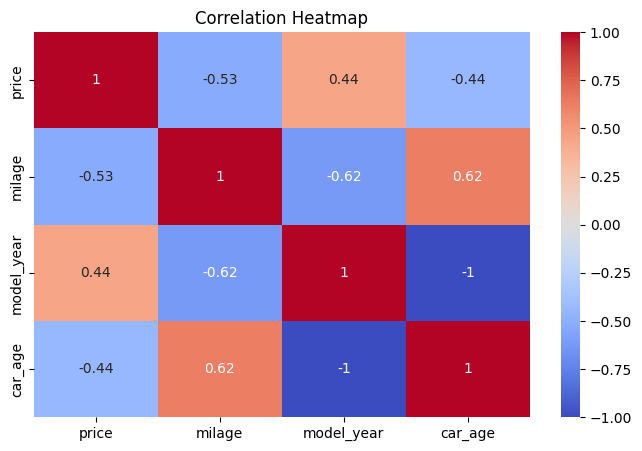

In [10]:
plt.figure(figsize=(8, 5))
sns.heatmap(model_data[["price", "milage", "model_year", "car_age"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## 8. Select Features and Target


In [11]:
numeric_features = [
    "model_year",
    "milage",
    "car_age",
    "log_milage",
    "age_mileage",
    "horsepower",
    "engine_liters",
    "cylinders",
]
categorical_features = ["brand_group", "fuel_type", "transmission", "accident", "clean_title"]

X = model_data[numeric_features + categorical_features]
y = np.log(model_data["price"])

X.head()


,model_year,milage,car_age,log_milage,age_mileage,horsepower,engine_liters,cylinders,brand_group,fuel_type,transmission,accident,clean_title
0,2013,51000.0,13,10.839601,140.914807,300.0,3.7,6.0,Ford,E85 Flex Fuel,Automatic,At least 1 accident or damage reported,Yes
1,2021,34742.0,5,10.455733,52.278667,NaN,3.8,6.0,Hyundai,Gasoline,Automatic,At least 1 accident or damage reported,Yes
2,2022,22372.0,4,10.015610,40.062441,NaN,3.5,NaN,Lexus,Gasoline,Automatic,None reported,Unknown
3,2015,88900.0,11,11.395279,125.348065,354.0,3.5,6.0,INFINITI,Hybrid,Automatic,None reported,Yes
4,2021,9835.0,5,9.193804,45.969022,NaN,2.0,4.0,Audi,Gasoline,Automatic,None reported,Unknown


## 9. Train-Test Split


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 3184
Testing rows: 797


## 10. Build scikit-learn MLR Pipeline

Car prices are right-skewed, so the model is trained on `log(price)`, like the reference repo.
This is still Multiple Linear Regression; the target transformation just makes the linear model fit the price distribution better.


In [13]:
from sklearn.impute import SimpleImputer
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

mlr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

mlr_model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['model_year', 'milage',
                                                   'car_age', 'log_milage',
                                                   'age_mileage', 'horsepower',
                                                   'engine_liters',
                                                   'cylinders']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['brand_group', 'fuel_type',
                                                   'transmission', 'accident',
                                                   'clean_title'])])),
                ('model', LinearRegression())])

## 11. Train the Multiple Linear Regression Model


In [14]:
mlr_model.fit(X_train, y_train)
print("MLR model training completed.")


MLR model training completed.


## 12. Evaluate the Model


In [15]:
y_pred = mlr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MAE  : 0.2623
RMSE : 0.3661
R2   : 0.8165


In [16]:
comparison = pd.DataFrame(
    {
        "Actual Price": np.exp(y_test.values),
        "Predicted Price": np.exp(y_pred),
        "Actual log(price)": y_test.values,
        "Predicted log(price)": y_pred,
        "Log Error": y_test.values - y_pred,
    }
)

comparison.head(10)


,Actual Price,Predicted Price,Actual log(price),Predicted log(price),Log Error
0,35345.0,33561.536176,10.472912,10.421136,0.051776
1,15000.0,16189.905762,9.615805,9.692143,-0.076338
2,10900.0,8006.826483,9.296518,8.988050,0.308468
3,21900.0,23351.333399,9.994242,10.058409,-0.064167
4,134000.0,152470.946285,11.805595,11.934729,-0.129134
5,49995.0,33081.993557,10.819678,10.406744,0.412934
6,18500.0,17802.375217,9.825526,9.787087,0.038439
7,7000.0,15771.448680,8.853665,9.665957,-0.812291
8,42995.0,33837.540625,10.668839,10.429326,0.239513
9,91000.0,109687.757544,11.418615,11.605393,-0.186778


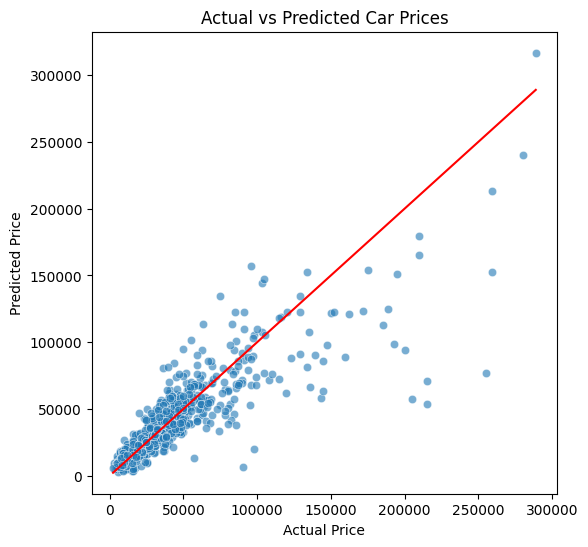

In [17]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=np.exp(y_test), y=np.exp(y_pred), alpha=0.6)
plt.plot([np.exp(y_test).min(), np.exp(y_test).max()], [np.exp(y_test).min(), np.exp(y_test).max()], color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()


## 13. MLR Coefficients


In [18]:
feature_names = mlr_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = mlr_model.named_steps["model"].coef_

coef_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Coefficient": coefficients,
    }
).sort_values("Coefficient", ascending=False)

coef_df.head(15)


,Feature,Coefficient
27,cat__brand_group_Lamborghini,1.311427
11,cat__brand_group_Bentley,0.800833
39,cat__brand_group_Porsche,0.667255
21,cat__brand_group_Hummer,0.453063
37,cat__brand_group_Other,0.410641
28,cat__brand_group_Land,0.275122
34,cat__brand_group_Mercedes-Benz,0.267212
20,cat__brand_group_Honda,0.209895
29,cat__brand_group_Lexus,0.205809
44,cat__brand_group_Toyota,0.190954


In [19]:
coef_df.tail(15)


,Feature,Coefficient
33,cat__brand_group_Mazda,-0.133687
52,cat__transmission_CVT,-0.145219
1,num__milage,-0.151651
26,cat__brand_group_Kia,-0.159121
0,num__model_year,-0.169393
31,cat__brand_group_MINI,-0.182496
49,cat__fuel_type_Hybrid,-0.272306
50,cat__fuel_type_Plug-In Hybrid,-0.317346
22,cat__brand_group_Hyundai,-0.336567
15,cat__brand_group_Chrysler,-0.372615


## 14. Predict Price for a New Car


In [20]:
sample_car = pd.DataFrame(
    {
        "milage": [35000],
        "model_year": [2021],
        "car_age": [current_year - 2021],
        "log_milage": [np.log1p(35000)],
        "age_mileage": [(current_year - 2021) * np.log1p(35000)],
        "horsepower": [300],
        "engine_liters": [3.5],
        "cylinders": [6],
        "brand_group": ["Toyota"],
        "fuel_type": ["Gasoline"],
        "transmission": ["Automatic"],
        "accident": ["None reported"],
        "clean_title": ["Yes"],
    }
)

predicted_log_price = mlr_model.predict(sample_car)[0]
predicted_price = np.exp(predicted_log_price)
print(f"Predicted car price: ${predicted_price:,.2f}")


Predicted car price: $43,690.95


## Conclusion

This notebook uses `scikit-learn` to train a Multiple Linear Regression model.
MLR is useful as an interpretable baseline, because the coefficient table shows how each encoded feature influences price.
